# **Laboratorio 1**

Laura Sanchez Bernal - 202411353

Baruc Jeronimo Triana - 202416093

## **Actividades a realizar**

1. **Exploración de los datos:** Utilizando las funcionalidades de la librería pandas. Recuerda que este paso es muy importante para conocer el conjunto de datos compartido, determinar problemas de calidad (por ejemplo, valores ausentes y registros duplicados) y tomar decisiones relacionadas con la preparación de los datos para el algoritmo de aprendizaje.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


datos = pd.read_csv('./data/Datos lab 1.csv', )
datosPrueba = pd.read_csv('./data/Datos Test Lab 1.csv', )

data = datos.copy()
dataPrueba = datosPrueba.copy()

### **Analisis de datos**

In [3]:
dict = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


#### **Clasificacion columnas**

**Cuantitativas_continuas:** presion_media, presion_min, presion_max, presion_desv, humedad_media, humedad_min, humedad_max, humedad_desv, viento_media, viento_min, viento_max, viento_desv, rafaga_media, rafaga_min, rafaga_max, rafaga_desv, viento_norte, viento_este, direccion_viento, temp_max_manana

**Cuantitativas_discretas:** registros_del_dia, anio, dia_del_anio

**Cualitativas_ordinales:** Ninguna

**Cualitativas_nominales:** estacion_anio, mes, sector_viento


Nuestro conjunto de datos está compuesto por 2576 registros (filas) y 27 variables (columnas), principalmente de tipo numérico (23 columnas float64) y 4 columnas de tipo texto (str), correspondientes a variables como fecha y sector_viento.


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

## **Completitud**

El dataset tiene faltantes distribuidos en todas las columnas. Se calculó el porcentaje de valores faltantes por columna, encontrando que las 27 variables tienen datos nulos, en un rango relativamente uniforme entre 2.4% y 3.7%.

In [ ]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

temp_max_manana      0.036879
viento_min           0.035326
mes                  0.034161
estacion_anio        0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
presion_desv         0.031056
humedad_min          0.031056
viento_norte         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
humedad_media        0.028727
presion_min          0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
viento_este          0.024845
presion_max          0.024845
humedad_desv         0.023680
dtype: float64

## **Consistencia**

**Sector_viento:** La columna sector_viento debería tener solo 8 categorías (N, NE, E, SE, S, SO, O, NO) según el diccionario de datos, pero no estan presentando consistencia.

**Estacion_anio:** La columna estacion_anio debería tener solo 4 categorías (invierno, primavera, verano u otoño) según el diccionario de datos, pero no estan presentando consistencia.

In [ ]:
data['sector_viento'].value_counts()

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
ne            19
South         19
NORTHEAST     17
Sur           16
Noreste       12
SOUTH          8
o              8
no             6
NORTH          6
West           5
WEST           5
EAST           4
North          4
East           4
SOUTHEAST      3
Sureste        3
Oeste          3
Noroeste       3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

In [ ]:
data['estacion_anio'].value_counts()

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
PRIMAVERA                10
Primavera                10
Invierno                  9
Verano                    9
invierno                  9
INVIERNO                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

In [ ]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


## **Validez**

1. **Presion_media**: Al revisar la columna presion_media, se encontro un dato que no tiene sentido, el valor máximo es 9939.9, cuando la presión atmosférica normal está entre 950 y 1050 mbar aproximadamente. Esto se confirma al compararlo con presion_min y presion_max, cuyos máximos sí son razonables (1012.3 y 1013.9). Como la media diaria siempre debería estar entre el mínimo y el máximo del día.

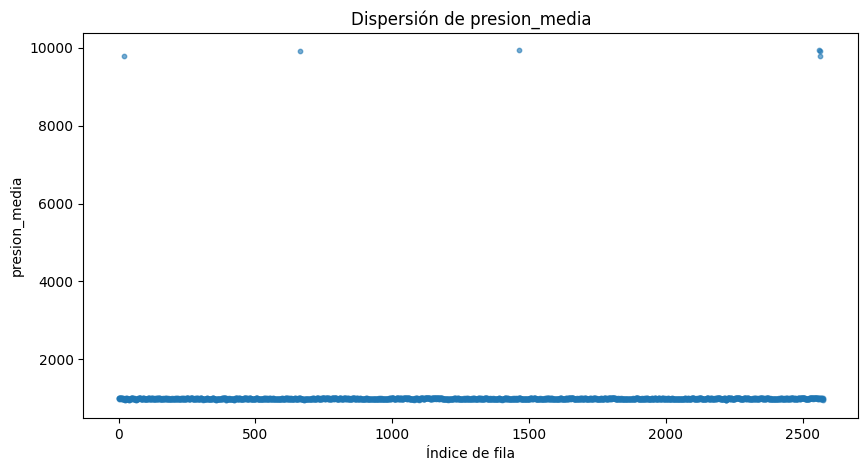

np.int64(6)

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(data.index, data['presion_media'], alpha=0.6, s=10)
plt.xlabel('Índice de fila')
plt.ylabel('presion_media')
plt.title('Dispersión de presion_media')
plt.show()

(data['presion_media'] > 1050).sum()

2. **Humedad_media**: Encontramos que 776 registros (cerca del 30% del dataset) tienen valores menores a 1, como 0.91 o 0.92, mientras que el resto de los datos está en escala de porcentaje, con valores como 76.4 o 89.4. El diagrama de dispersión confirma este problema pues se observan dos bandas de puntos claramente separadas, una entre 40 y 100 y otra pegada a 0. Esto indica que esos 776 registros probablemente se guardaron como proporción (0 a 1) en lugar de porcentaje (0 a 100).

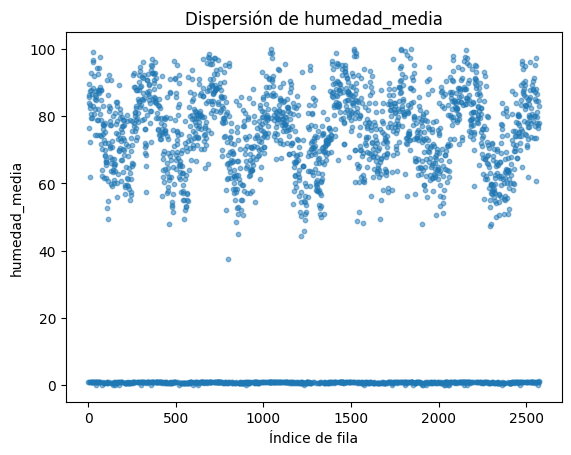

np.int64(776)

In [ ]:

plt.scatter(data.index, data['humedad_media'], alpha=0.5, s=10)
plt.xlabel('Índice de fila')
plt.ylabel('humedad_media')
plt.title('Dispersión de humedad_media')
plt.show()

(data['humedad_media'] < 1).sum()

3. **Rafaga_min y viento_norte:** Se encontró un registro con un valor centinela de -9999 en rafaga_min, lo cual no es coherente. Al revisar la fila completa, se identificó que no es un error aislado, la fila presenta múltiples valores irregulares pues en viento_norte el valor es -1250.46 m/s, una magnitud físicamente imposible para el viento.

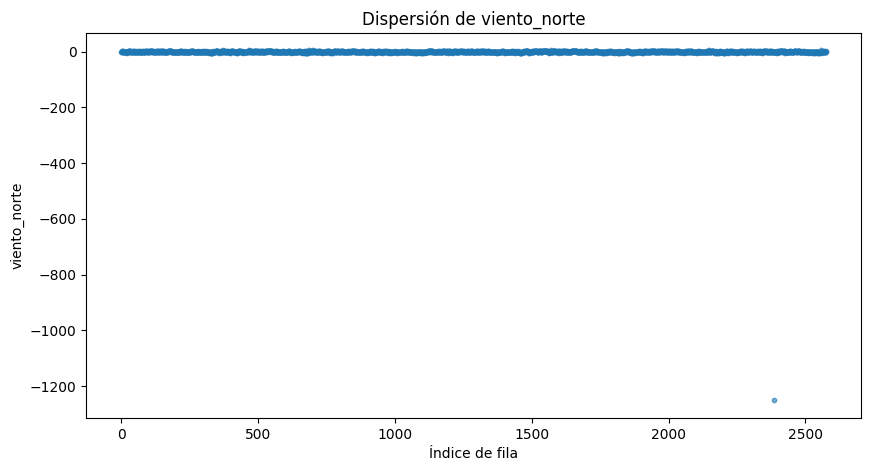

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
2384,2015-07-13,989.8826,988.77,990.94,0.5409,82.5317,60.5,94.6,10.118,NaN,...,-1250.4633,3.5736,179.8363,144.0,2015.0,NaN,verano,July,S,22.26


In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(data.index, data['viento_norte'], alpha=0.6, s=10)
plt.xlabel('Índice de fila')
plt.ylabel('viento_norte')
plt.title('Dispersión de viento_norte')
plt.show()

data.loc[data['rafaga_min'] == -9999]


4. **Registros_del_dia:** Se encontraron 4 registros con más de 144 mediciones por día, el máximo esperado según el diccionario de datos

In [ ]:
data.loc[data['registros_del_dia'] > 144, ['fecha','registros_del_dia']]

,fecha,registros_del_dia
546,2010-07-01,287.0
547,2010-07-02,145.0
1904,2014-03-20,222.0
1905,2014-03-21,249.0


5. **temp_max_manana:** El valor máximo (63.05°C) parecía un outlier extremo, pero al investigarlo se encontró que corresponde a una fila duplicada en el dataset (ver sección de Unicidad), no a un error de temperatura. Una vez eliminados los duplicados, el rango de la variable queda dentro de valores climáticamente razonables.

In [4]:
data['temp_max_manana'].describe()

count    2481.000000
mean       13.863309
std         9.296199
min       -15.230000
25%         7.310000
50%        14.310000
75%        20.460000
max        63.050000
Name: temp_max_manana, dtype: float64

<Axes: >

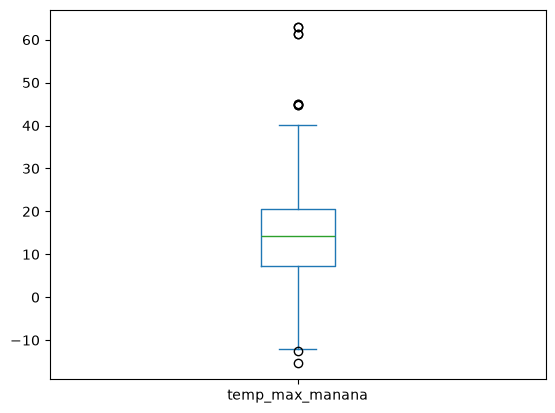

In [5]:
data['temp_max_manana'].plot.box()

## **Unicidad**

Se identificaron 4 pares de filas completamente duplicadas en el dataset con los mismos valores en las 27 columnas (Esto es correspondiente a 8 filas involucradas). Este hallazgo es relevante porque una de las columnas afectadas es temp_max_manana, cuyo valor máximo (63.05°C) inicialmente parecía un outlier, pero en realidad se debía a que el registro estaba duplicado y no a un error real de temperatura.

In [ ]:
n_duplicados = int(data.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

data[data.duplicated(keep=False)].sort_values('fecha')

Número de registros duplicados: 8


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412


## **Formato automático para el entendimiento de los datos**

In [20]:
from ydata_profiling import ProfileReport

In [21]:
profile = ProfileReport(
    data,
    title="Reporte de Análisis Exploratorio",
    explorative=True
)

In [24]:
profile.to_file("reporte_analisis_exploratorio.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 67.69it/s]
